In [1]:
import numpy as np
import scvelo as scv
import scanpy as sc
import pandas as pd
import topovelo as tpv
import matplotlib.pyplot as plt

In [3]:
DATA_DIR = ''
DATA_NAME = 'slide-seq-adult-cortex'

In [4]:
adata = sc.read_h5ad(f'{DATA_DIR}/{DATA_NAME}-out.h5ad')

# 1. Velocity Stream and Cell Developmental Time

In [5]:
stream_plot_config = {
    'width': 3,
    'real_aspect_ratio': True,
    'markersize': 100,
    'density': 0.8,
    'linewidth': 2.5,
    'arrow_size': 2,
}

Overwriting the original KNN graph! (.uns, .obsp)


---   Plotting  Results   ---
Computing a spatial graph using KNN on spatial with k=50
computing neighbors
    finished (0:00:03) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/36 cores)


  0%|          | 0/2525 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


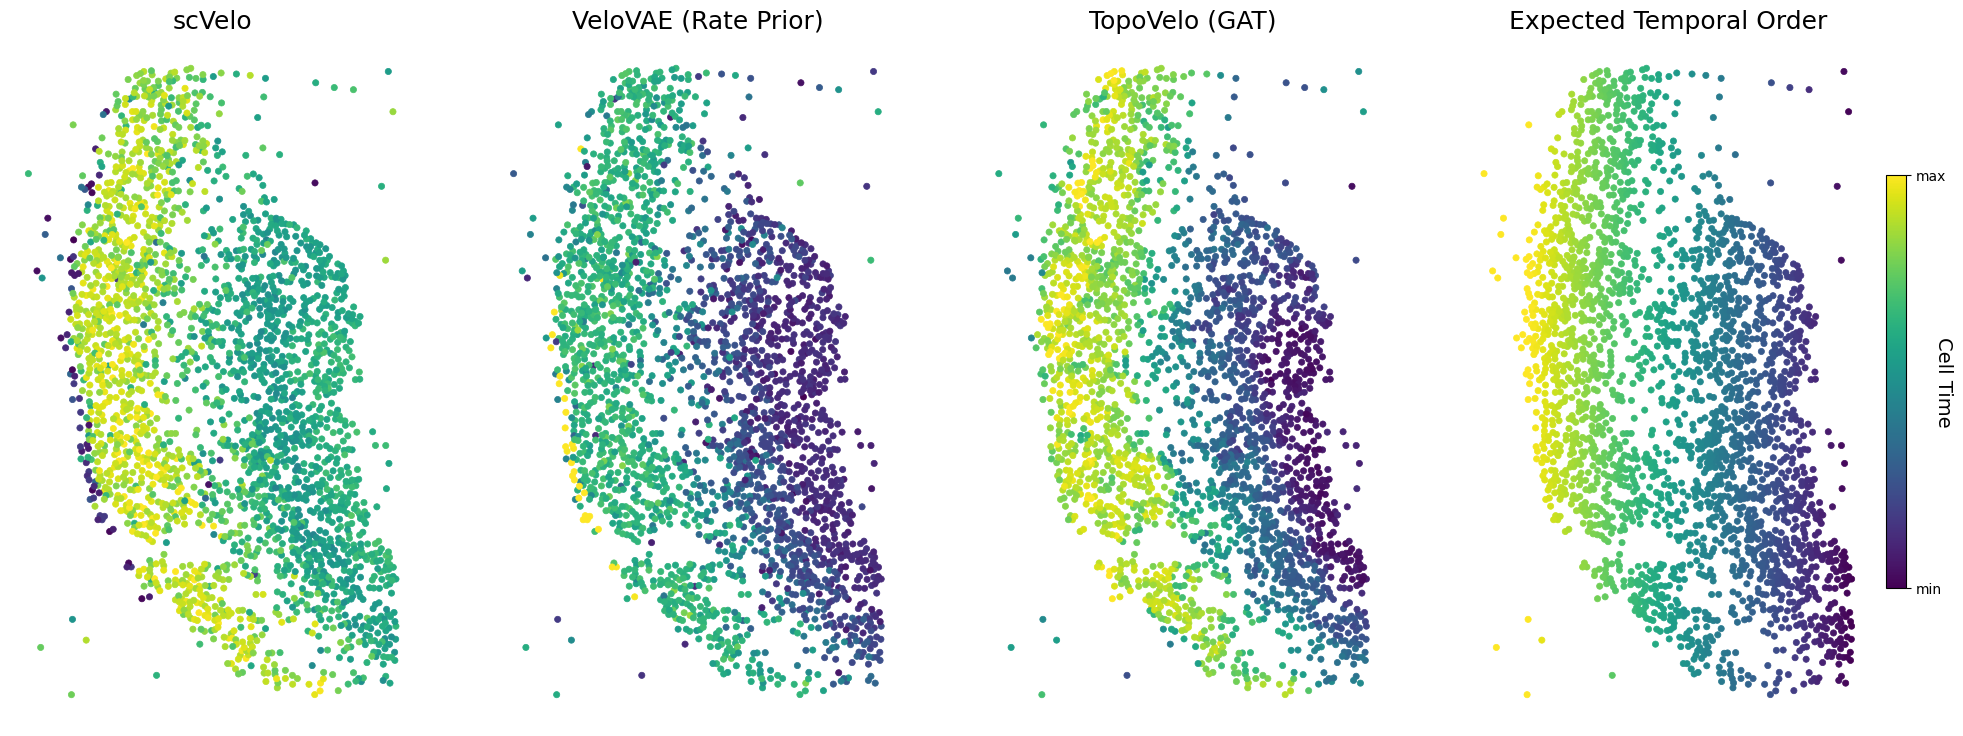

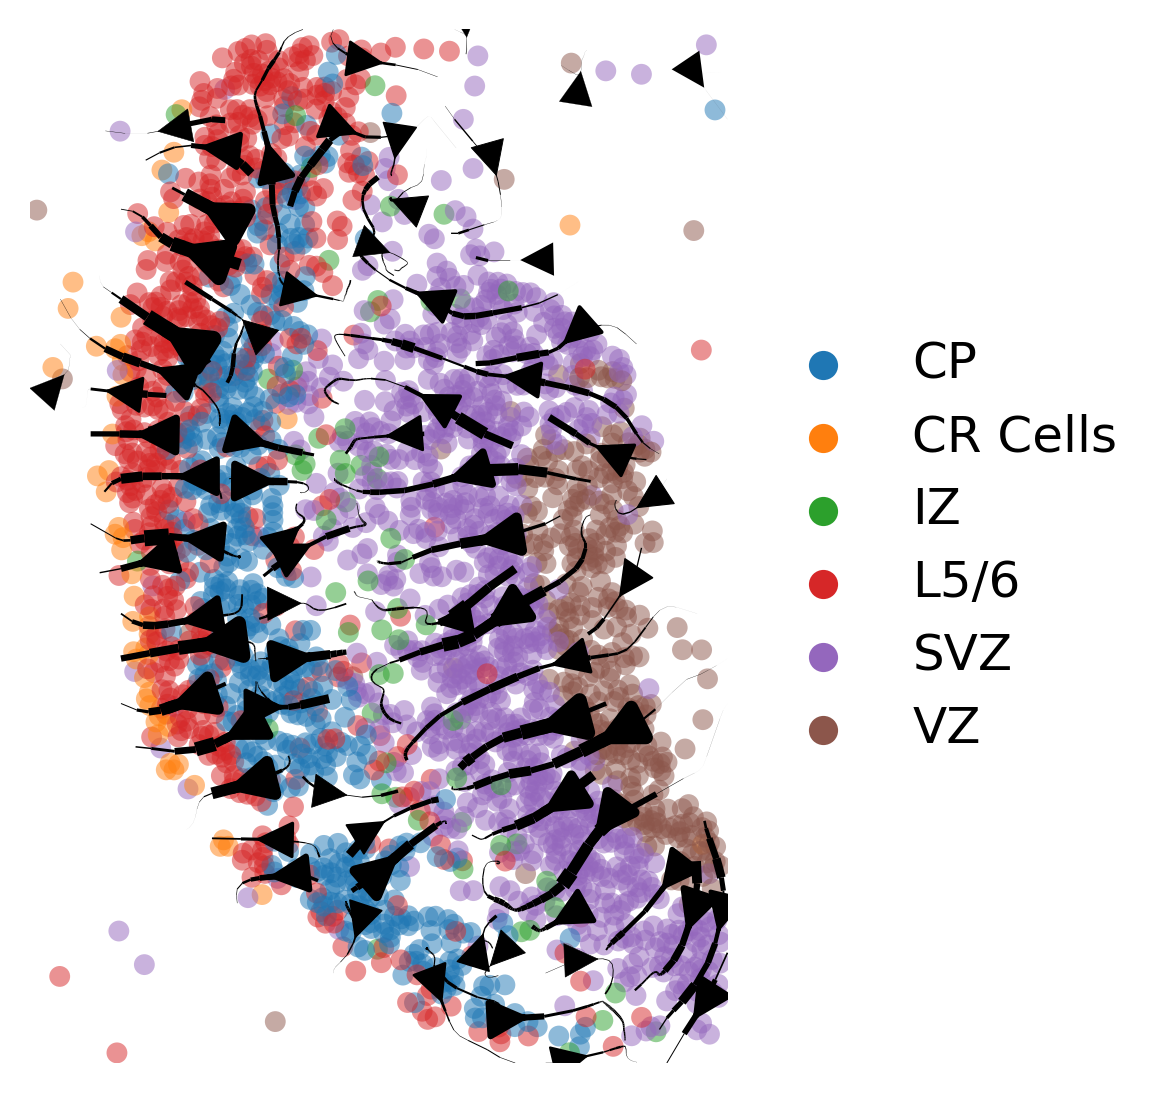

Overwriting the original KNN graph! (.uns, .obsp)


Computing a spatial graph using KNN on spatial with k=50
computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/36 cores)


  0%|          | 0/2525 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'fullvb_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'fullvb_velocity_spatial', embedded velocity vectors (adata.obsm)


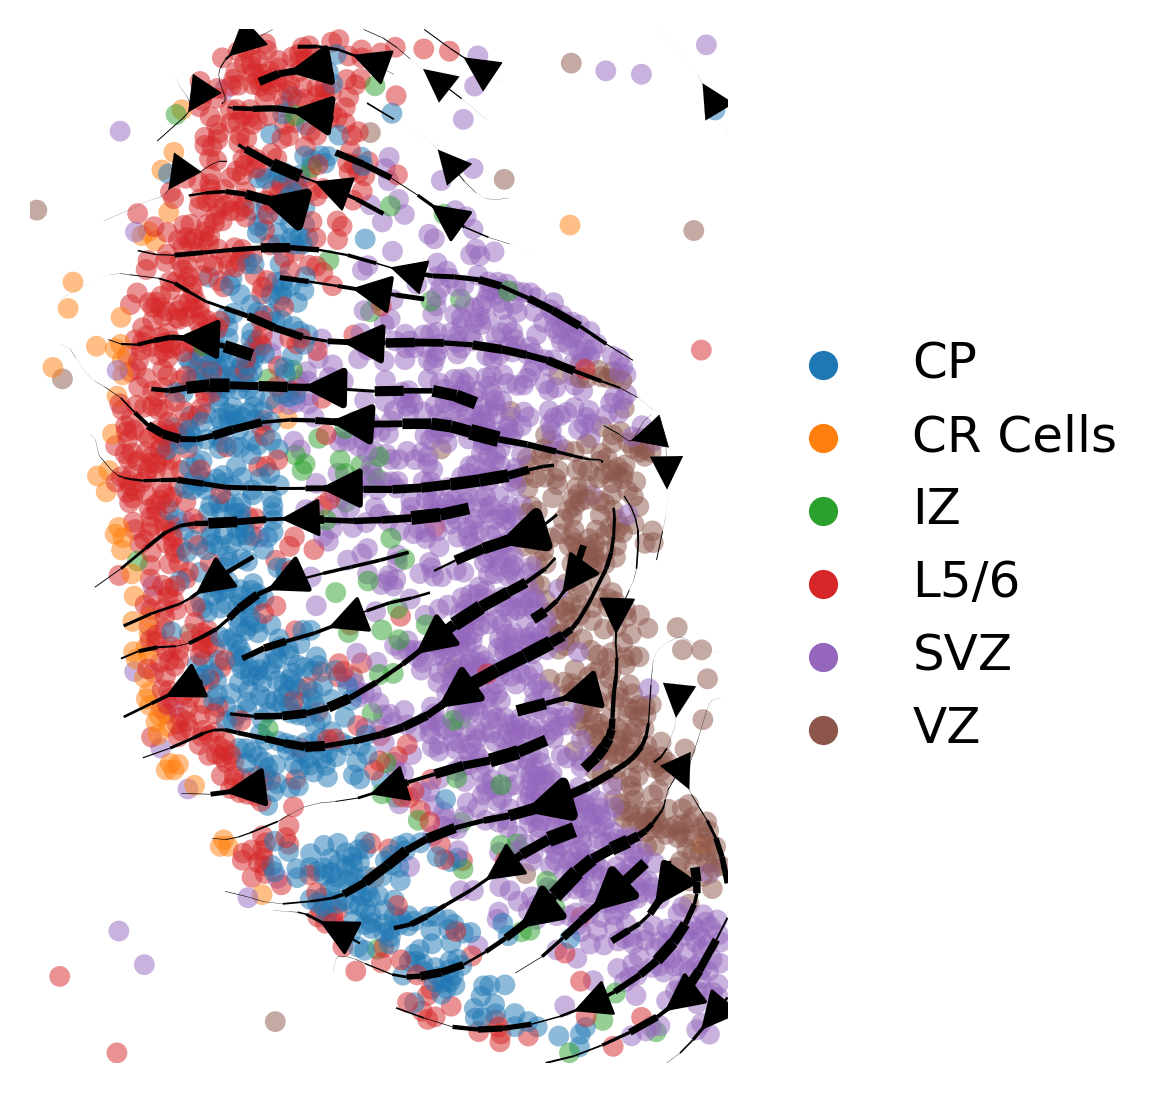

Overwriting the original KNN graph! (.uns, .obsp)


Computing a spatial graph using KNN on spatial with k=50
computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/36 cores)


  0%|          | 0/2525 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'gat_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'gat_velocity_spatial', embedded velocity vectors (adata.obsm)


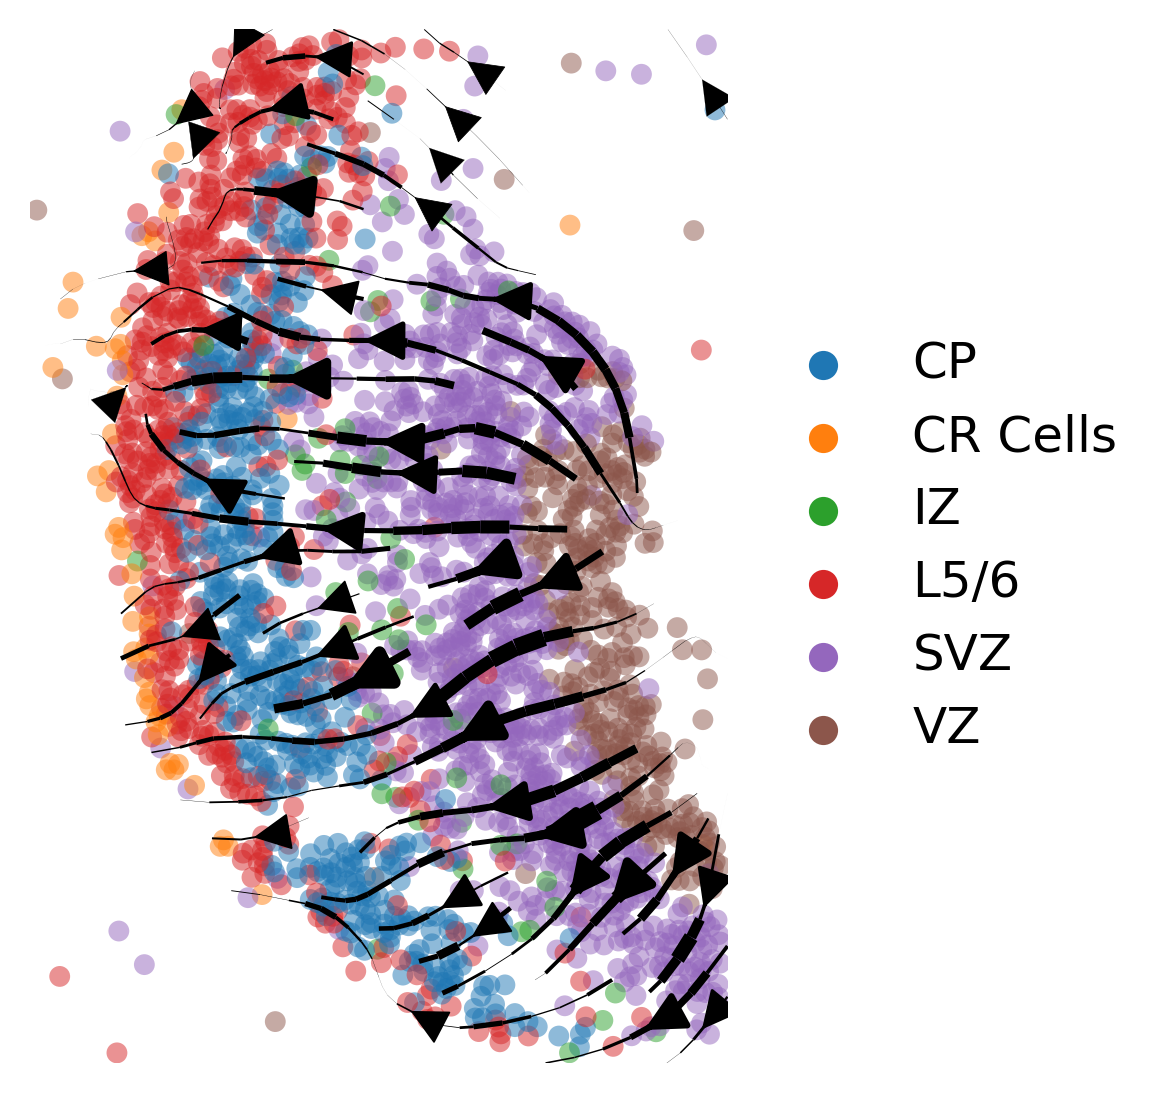

In [6]:
_ = tpv.post_analysis(
    adata,
    DATA_NAME,
    ['scVelo', 'VeloVAE (Rate Prior)', 'TopoVelo (GAT)'],
    ['fit', 'fullvb', 'gat'],
    plot_type=['time', 'cell velocity'],
    stream_plot_config=stream_plot_config,
    dpi=300
)

# 2. Velocity on UMAP

In [7]:
stream_plot_config = {
    'width': 3,
    'real_aspect_ratio': True,
    'markersize': 100,
}

---   Plotting  Results   ---
computing velocity graph (using 1/36 cores)


  0%|          | 0/2525 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


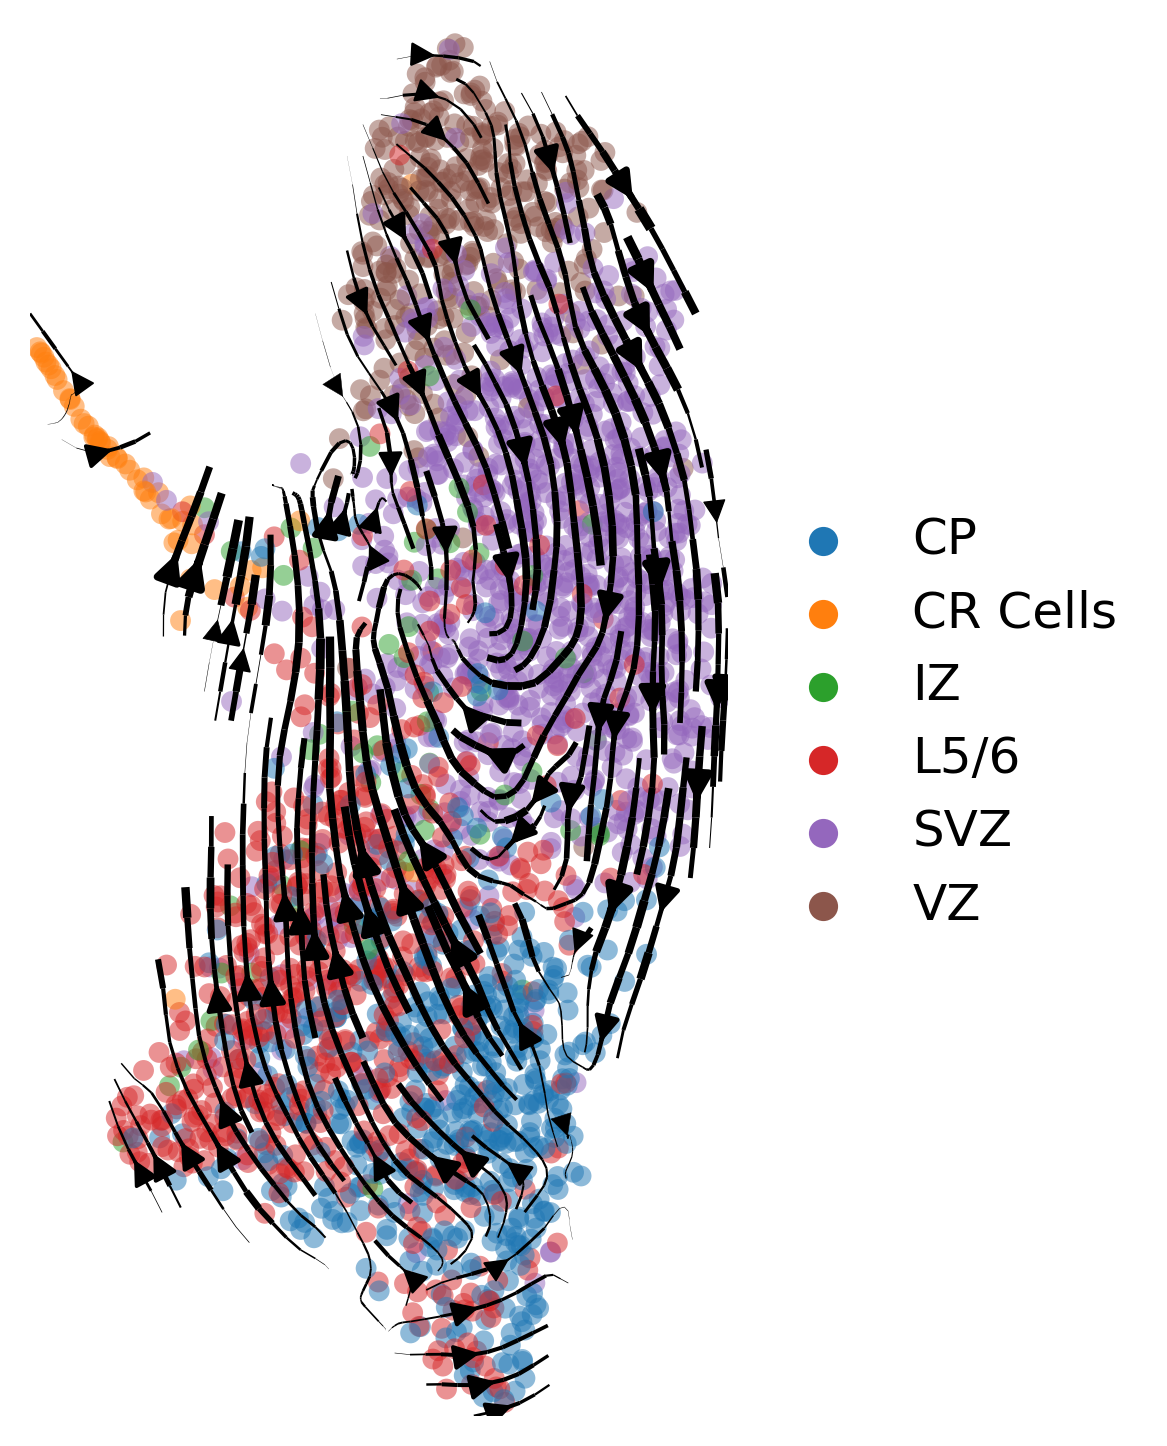

computing velocity graph (using 1/36 cores)


  0%|          | 0/2525 [00:00<?, ?cells/s]

    finished (0:00:02) --> added 
    'fullvb_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'fullvb_velocity_umap', embedded velocity vectors (adata.obsm)


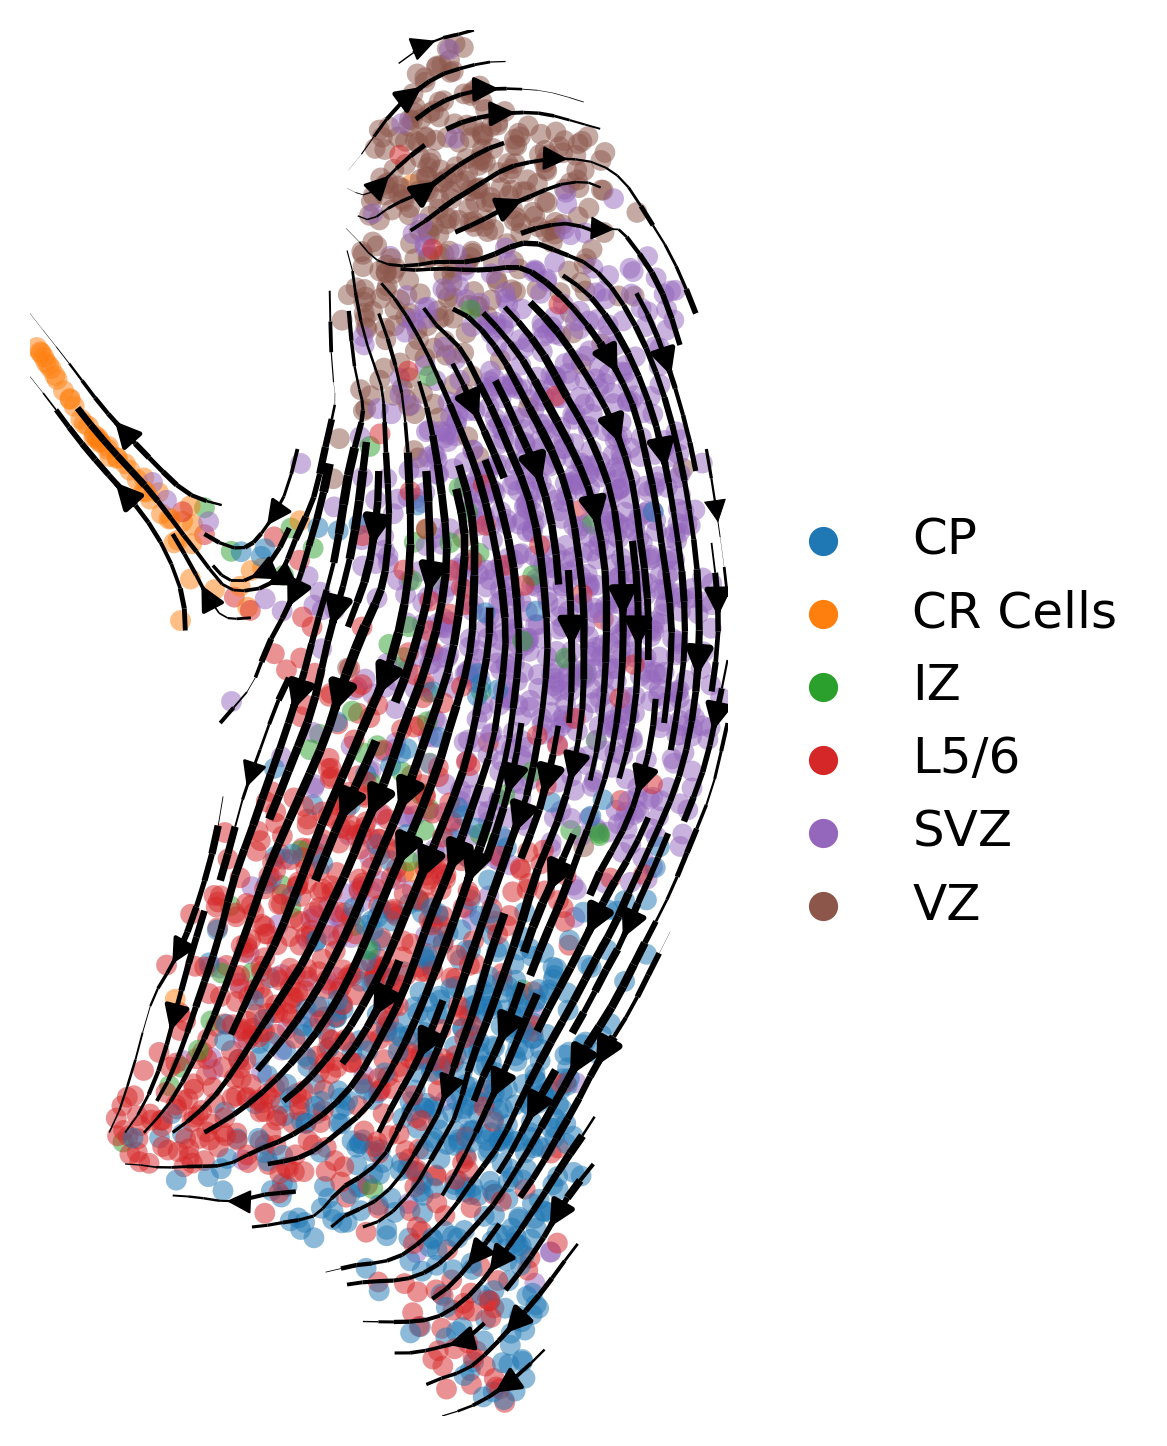

computing velocity graph (using 1/36 cores)


  0%|          | 0/2525 [00:00<?, ?cells/s]

    finished (0:00:02) --> added 
    'gat_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'gat_velocity_umap', embedded velocity vectors (adata.obsm)


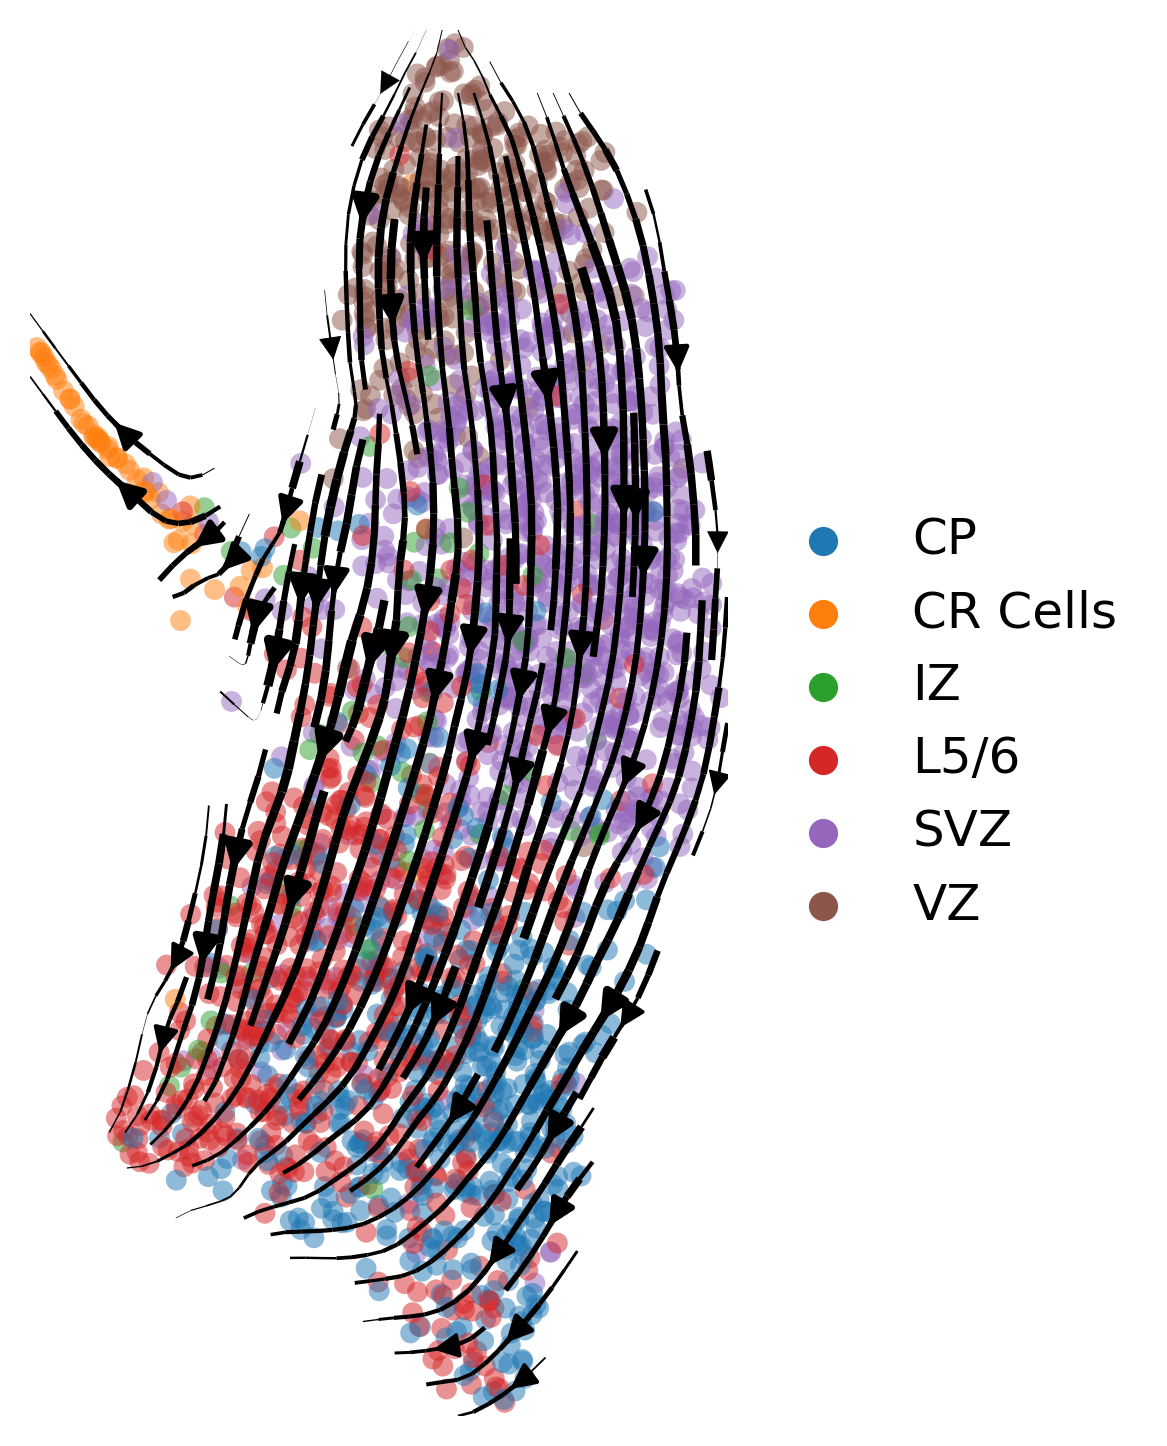

In [8]:
_ = tpv.post_analysis(
    adata,
    'main_brain',
    ['scVelo', 'VeloVAE (Rate Prior)', 'TopoVelo (GAT)'],
    ['fit', 'fullvb', 'gat'],
    spatial_velocity_graph=False,
    plot_basis='umap',
    plot_type=['embed velocity'],
    stream_plot_config=stream_plot_config,
    dpi=300
)

In [9]:
FIG_DIR = ''

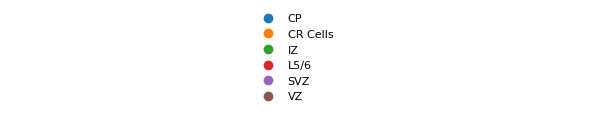

In [10]:
tpv.plotting.plot_legend(adata, 'clusters', ncol=1, fontsize=8)

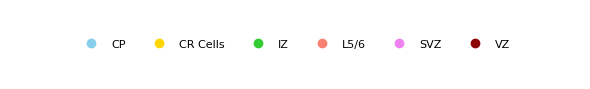

In [12]:
tpv.plotting.plot_legend(adata,
                         'clusters',
                         palette=['skyblue', 'gold', 'limegreen', 'salmon', 'violet', 'darkred'],
                         fontsize=8,
                         ncol=6)

# 3. Cell Velocity in Real Physical Units

In [13]:
x_spatial = adata.obsm['X_spatial']
t = adata.obs['gat_time'].to_numpy()

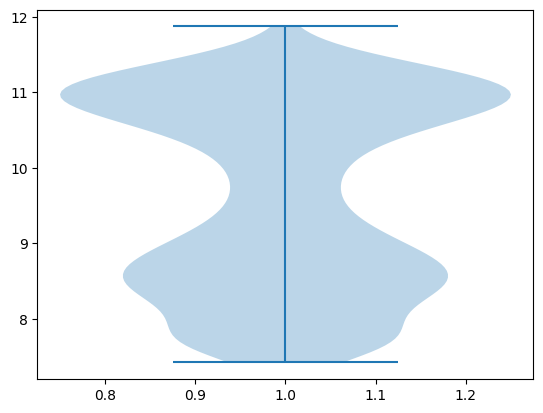

In [14]:
plt.figure()
plt.violinplot(t)
plt.show()

In [15]:
from sklearn.neighbors import NearestNeighbors
t = adata.obs['gat_time'].to_numpy()
t = (t - t.min()) / (t.max() - t.min()) * 20
delta_xy = adata.obsm['gat_velocity_spatial']
delta_t = []

knn = NearestNeighbors(n_neighbors=30).fit(adata.obsm['X_pca'])
knn_ind = knn.kneighbors(adata.obsm['X_pca'], return_distance=False)
for i, nbs in enumerate(knn_ind):
    delta_t.append(np.mean(t[i] - t[nbs]))


v = delta_xy / np.array(delta_t).reshape(-1, 1)
v_mag = np.linalg.norm(v, axis=1)

In [16]:
q1 = np.quantile(v_mag, 0.25)
q3 = np.quantile(v_mag, 0.75)
v_mag = np.clip(v_mag, None, q3 + (q3 - q1) * 1.5)

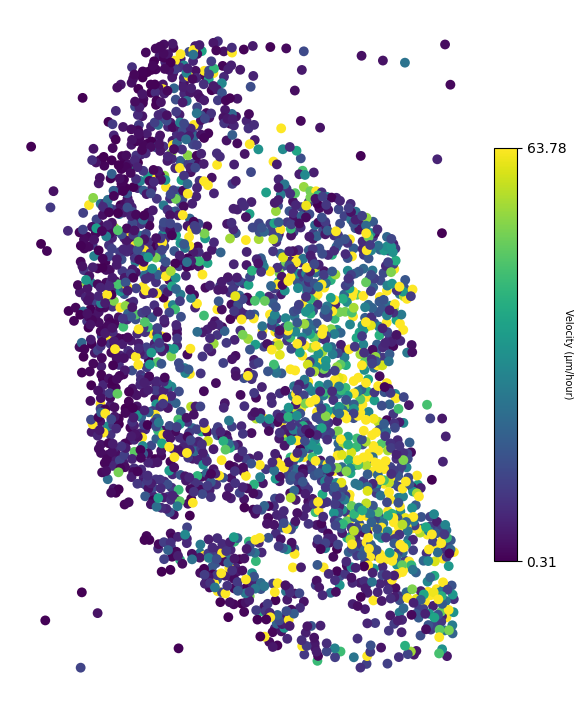

In [17]:
tpv.plotting.plot_heatmap(
    v_mag,
    adata.obsm['X_spatial'],
    colorbar_name="Velocity (µm/hour)",
    width=6,
    real_aspect_ratio=True,
    markersize=50
)

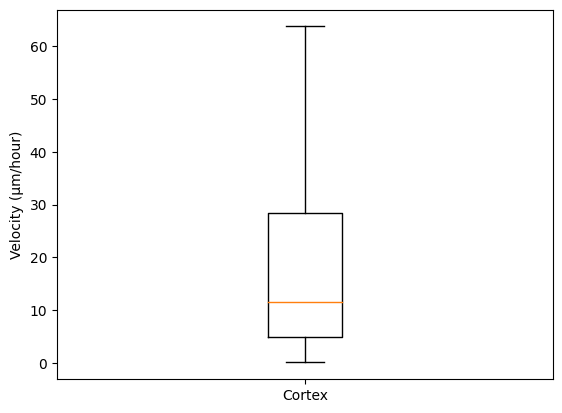

In [18]:
plt.figure()
plt.boxplot(v_mag, showfliers=False)
plt.xticks([1],['Cortex'])
plt.ylabel('Velocity (µm/hour)')
plt.show()